In [1]:
from transformers import CLIPProcessor, CLIPModel

In [3]:
from PIL import Image

In [5]:
import matplotlib.pyplot as plt

In [6]:
import torch

In [9]:
print("All imports successful!")

All imports successful!


In [11]:
print("PyTorch versionL: ", torch.__version__)

PyTorch versionL:  2.11.0


In [12]:
# This downloads the model (~600MB, only happens once)
# CLIPModel is the neural network
# CLIPProcessor handles converting images/text into the right format for the model

In [13]:
print("Loading CLTP model...(first time takes ~1 min to download)")

Loading CLTP model...(first time takes ~1 min to download)


In [15]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
print("Model loaded successfully!")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Model loaded successfully!


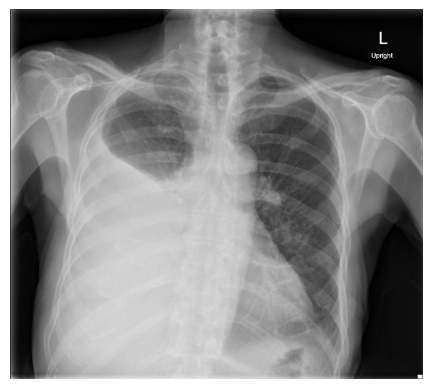

Image size:  (778, 697)


In [40]:
image = Image.open("data/Pleural-Effusion-AP-Chest-Xray.-JETem-2016.jpg").convert("RGB")
plt.imshow(image, cmap = "gray")
plt.axis("off")
plt.show()

print("Image size: ", image.size)

In [41]:
candidate_texts = [
    "normal chest x-ray with no findings",
    "pneumonia with consolidation  in the lungs",
    "cardiomegally with enlarged heart",
    "pleural effusion with fluid around the lungs",
    "pulmonary edema"    
]

inputs = processor(
    text = candidate_texts,
    images = image,
    return_tensors = 'pt',
    padding = True
)

with torch.no_grad():
    outputs = model(**inputs)

probs = outputs.logits_per_image.softmax(dim=1)
print("Results:")
print("-" * 50)

for text, prob in zip(candidate_texts, probs[0]): 
    print(f"{prob.item()*100:.1f} ->{text}")

Results:
--------------------------------------------------
85.9 ->normal chest x-ray with no findings
5.0 ->pneumonia with consolidation  in the lungs
2.5 ->cardiomegally with enlarged heart
4.9 ->pleural effusion with fluid around the lungs
1.7 ->pulmonary edema
